In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df_raw = pd.read_csv("/Users/chris/Desktop/ChristianBDA2026/data/symbol_info_3-25.csv")
df = df_raw[
    (df_raw["is_etf"] == 0) &
    (df_raw["is_fund"] == 0) &
    (df_raw["is_actively_trading"] == 1) &
    (df_raw["market_cap"] > 0) &
    (df_raw["total_revenue"] > 0)
].copy()
df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df = df.replace([np.inf, -np.inf], np.nan)

Exercise 2.1 — Histogram: distribution of revenue
Create a histogram of `revenue_b` (revenue in billions). Your chart must include:
- 30 bins
- A color of your choice
- A **median** vertical line (orange dashed)
- A **mean** vertical line (red dotted)
- A meaningful title that describes the shape of the distribution
- Clean spines (remove top and right borders)

> **Think about it:** is the revenue distribution more or less skewed than the market cap distribution? Why?


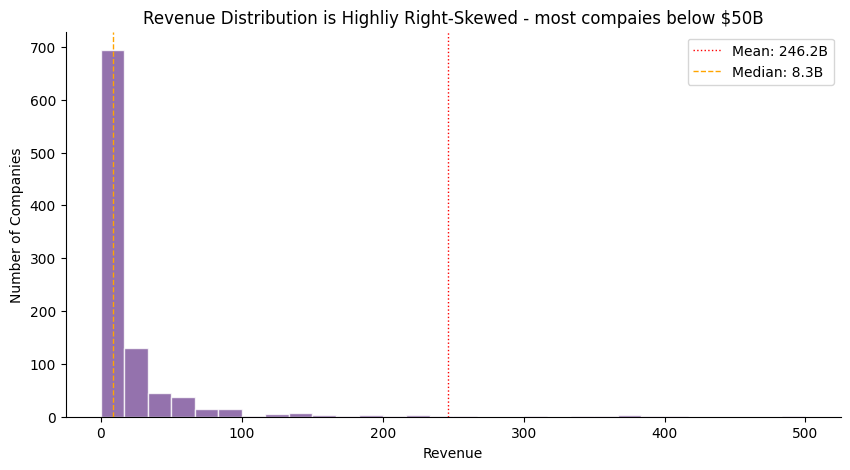

In [50]:

revenue = df['revenue_b'].dropna()

fig, ax = plt.subplots(figsize = (10, 5))

ax.hist(

    revenue,
    bins = 30,
    range = (0, 500),
    color = '#7a4f99',
    edgecolor = 'White',
    alpha = 0.80
)

mean_value = revenue.mean()
median_value = revenue.median()


ax.axvline(mean_value, color = 'Red', linestyle = ":", linewidth = 1, label = f"Mean: {mean_value:,.1f}B")
ax.axvline(median_value, color = 'Orange', linestyle = "--", linewidth = 1, label = f"Median: {median_value:,.1f}B")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_title("Revenue Distribution is Highliy Right-Skewed - most compaies below $50B")
ax.set_xlabel("Revenue")
ax.set_ylabel("Number of Companies")
ax.legend()


plt.show()

### Exercise 2.2 — Bar chart: top 15 by revenue
Create a **horizontal bar chart** showing the 15 companies with the highest revenue. Requirements:
- Sort so the largest bar is at the top
- Add a **data label** on each bar showing the value in billions (e.g. `"$450B"`)
- Use a single solid color for all bars
- Add a meaningful title

> **Challenge:** color each bar differently based on `sector`. Add a legend.

### Exercise 2.3 — Side-by-side subplots
Create a figure with **1 row and 2 columns** (`plt.subplots(1, 2)`):
- **Left chart:** top 10 companies by `profit_margin_pct` (bar chart, horizontal)
- **Right chart:** top 10 companies by `revenue_growth_pct` (bar chart, horizontal)
- Both charts must have titles and axis labels
- Use `sharey=False` (the two rankings will differ)
- Add a `fig.suptitle()` with an overall title

> **Think about it:** do the same companies appear in both rankings? What does that tell you?

### Exercise 2.4 — Treemap
Install `squarify` if needed (`pip install squarify`). Create a treemap of the **top 30 companies** by market cap where:
- Rectangle area = `market_cap_b`
- Rectangle color = sector (use `plt.cm.tab20`)
- Label = `symbol + "\n" + market_cap value in billions`
- Add a legend for sectors
- Remove the axes (`ax.axis("off")`)

> **Think about it:** what information does the treemap convey that a bar chart cannot? When would you prefer a bar chart?

### Exercise 2.5 — Scatter plot: beta vs profit margin
Create a scatter plot where:
- X axis = `beta` (market risk)
- Y axis = `profit_margin_pct`
- Filter: keep only companies with beta between 0 and 3 and profit margin between -30 and 80
- Color the points by `sector` (use a colormap or manual mapping)
- Add a vertical reference line at `beta = 1` (the market average risk)
- Add a horizontal reference line at `profit_margin_pct = 0`
- Annotate the 5 largest companies (by market cap) with their ticker symbols

> **Think about it:** do high-beta companies tend to have higher or lower profit margins? What does beta = 1 mean?

### Exercise 2.6 — Boxplot: revenue growth by sector
Create a **horizontal boxplot** showing the distribution of `revenue_growth_pct` by sector. Requirements:
- Filter: keep only companies with revenue ≥ 1B and revenue growth between -30% and 100%
- Order sectors by **median** revenue growth (ascending)
- Style the boxes with a fill color, a red median line, and semi-transparent outlier markers
- Add a vertical reference line at 0
- Format the x-axis as percentages

> **Think about it:** which sector has the highest median growth? Which has the widest spread (most variance)?


### Exercise 2.7 — Bubble chart: your own investment candidates
Reproduce the "Growth vs Profitability vs Risk" bubble chart from the notebook, but change the selection criteria for annotated companies:
- Annotate the 8 companies that have **profit_margin_pct > 20%**, **revenue_growth_pct > 20%**, and **beta < 1.2**
- These are your "ideal" candidates: growing fast, profitable, low risk
- Add a title that reflects this selection logic

> **Think about it:** are any of these companies names you recognize? Does this shortlist make intuitive sense as an investment watchlist?